# Cancer Diagnosis — Exploratory Data Analysis & Correlation Study
**Dataset:** `cancer_final.csv` — 10,131 patients, 12 clinical features  
**Target:** `cancer_diagnosis` (yes / no)

## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = {'yes': '#E05252', 'no': '#5B8DB8'}
plt.rcParams['figure.dpi'] = 120

# ── Load ───────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/raw/cancer_final.csv', encoding='latin-1', sep=';')
df = df.drop(columns=['id'])

print(f'Shape: {df.shape}')
df.head()

Shape: (10131, 12)


,age,sex,sof,alcohol,tobacco,diabetes,tenesmus,previous_rt,rectorrhagia,cancer_diagnosis,intestinal_habit,digestive_family_history
0,64,man,yes,0,1,no,yes,no,yes,yes,4,no
1,72,woman,no,0,0,no,yes,no,no,no,1,no
2,55,man,yes,1,2,no,no,no,no,no,2,no
3,60,woman,yes,4,0,no,no,no,no,no,0,no
4,78,man,no,0,2,no,yes,no,no,no,5,no


## 2. Data Quality Check

In [3]:
print('=== DTYPES ===')
print(df.dtypes)
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())
print('\n=== NUMERIC SUMMARY ===')
df.describe()

=== DTYPES ===
age                         int64
sex                           str
sof                           str
alcohol                     int64
tobacco                     int64
diabetes                      str
tenesmus                      str
previous_rt                   str
rectorrhagia                  str
cancer_diagnosis              str
intestinal_habit            int64
digestive_family_history      str
dtype: object

=== MISSING VALUES ===
age                         0
sex                         0
sof                         0
alcohol                     0
tobacco                     0
diabetes                    0
tenesmus                    0
previous_rt                 0
rectorrhagia                0
cancer_diagnosis            0
intestinal_habit            0
digestive_family_history    0
dtype: int64

=== NUMERIC SUMMARY ===


,age,alcohol,tobacco,intestinal_habit
count,10131.000000,10131.000000,10131.000000,10131.000000
mean,62.440924,0.917580,0.613760,1.420492
std,11.158772,1.334047,0.754823,1.751961
min,40.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,0.000000,0.000000
50%,62.000000,0.000000,0.000000,0.000000
75%,70.000000,2.000000,1.000000,3.000000
max,92.000000,4.000000,2.000000,5.000000


## 3. Preprocessing

In [4]:
# ── Clean digestive_family_history: keep main categories ───────────────────
def clean_family_hist(v):
    v = str(v).strip().lower()
    if v == 'no':                         return 'no'
    if 'colon' in v:                      return 'yes(colon)'
    if 'gastric' in v:                    return 'yes(gastric)'
    if v.startswith('yes'):               return 'yes(other)'
    return 'unknown'

df['digestive_family_history'] = df['digestive_family_history'].apply(clean_family_hist)

# ── Binary yes/no → 1/0 ───────────────────────────────────────────────────
binary_cols = ['sof', 'diabetes', 'tenesmus', 'previous_rt', 'rectorrhagia', 'cancer_diagnosis']
for c in binary_cols:
    df[c] = (df[c].str.strip().str.lower() == 'yes').astype(int)

df['sex_enc']  = (df['sex'].str.strip().str.lower() == 'man').astype(int)   # 1=man, 0=woman

# ── Ordinal encode family history ─────────────────────────────────────────
fh_map = {'no': 0, 'yes(other)': 1, 'yes(colon)': 2, 'yes(gastric)': 3, 'unknown': -1}
df['family_hist_enc'] = df['digestive_family_history'].map(fh_map)

# ── Full numeric frame for correlation ────────────────────────────────────
num_cols = ['age', 'sex_enc', 'sof', 'alcohol', 'tobacco', 'diabetes',
            'tenesmus', 'previous_rt', 'rectorrhagia', 'intestinal_habit',
            'family_hist_enc', 'cancer_diagnosis']
df_num = df[num_cols].copy()

print('Processed columns:', df_num.columns.tolist())
df_num.head()

Processed columns: ['age', 'sex_enc', 'sof', 'alcohol', 'tobacco', 'diabetes', 'tenesmus', 'previous_rt', 'rectorrhagia', 'intestinal_habit', 'family_hist_enc', 'cancer_diagnosis']


,age,sex_enc,sof,alcohol,tobacco,diabetes,tenesmus,previous_rt,rectorrhagia,intestinal_habit,family_hist_enc,cancer_diagnosis
0,64,1,1,0,1,0,1,0,1,4,0,1
1,72,0,0,0,0,0,1,0,0,1,0,0
2,55,1,1,1,2,0,0,0,0,2,0,0
3,60,0,1,4,0,0,0,0,0,0,0,0
4,78,1,0,0,2,0,1,0,0,5,0,0


## 4. Target Distribution

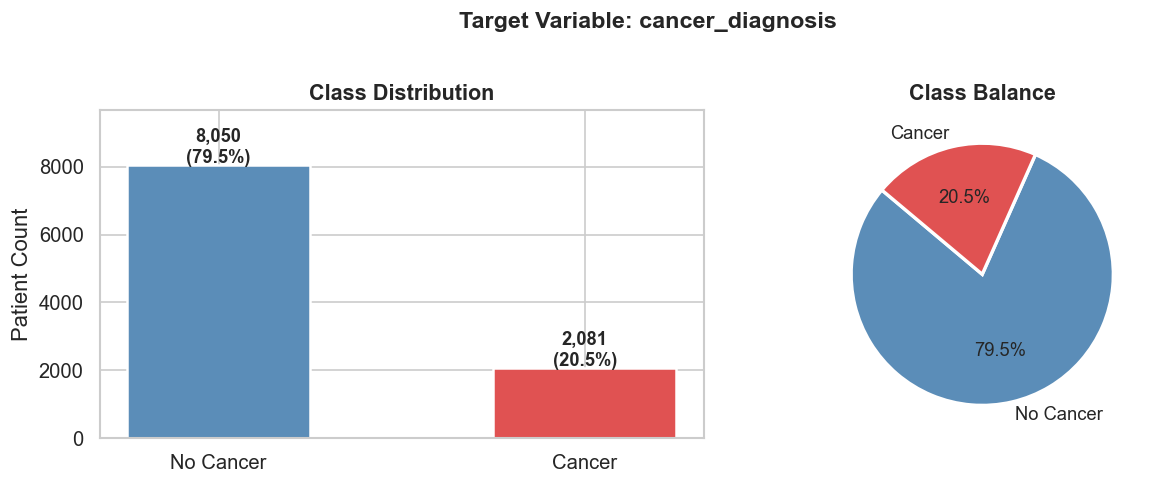


Imbalance ratio  →  No:8050  |  Yes:2081  |  Ratio 3.9:1


In [5]:
counts = df['cancer_diagnosis'].value_counts()
labels = ['No Cancer', 'Cancer']
vals   = [counts[0], counts[1]]
pcts   = [v/sum(vals)*100 for v in vals]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar
bars = axes[0].bar(labels, vals, color=[COLORS['no'], COLORS['yes']], edgecolor='white', linewidth=1.5, width=0.5)
for bar, v, p in zip(bars, vals, pcts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+60,
                 f'{v:,}\n({p:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Patient Count')
axes[0].set_ylim(0, max(vals)*1.2)

# Pie
axes[1].pie(vals, labels=labels, autopct='%1.1f%%',
            colors=[COLORS['no'], COLORS['yes']],
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 11})
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: cancer_diagnosis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f'\nImbalance ratio  →  No:{counts[0]}  |  Yes:{counts[1]}  |  Ratio {counts[0]/counts[1]:.1f}:1')

## 5. Univariate Distributions by Diagnosis

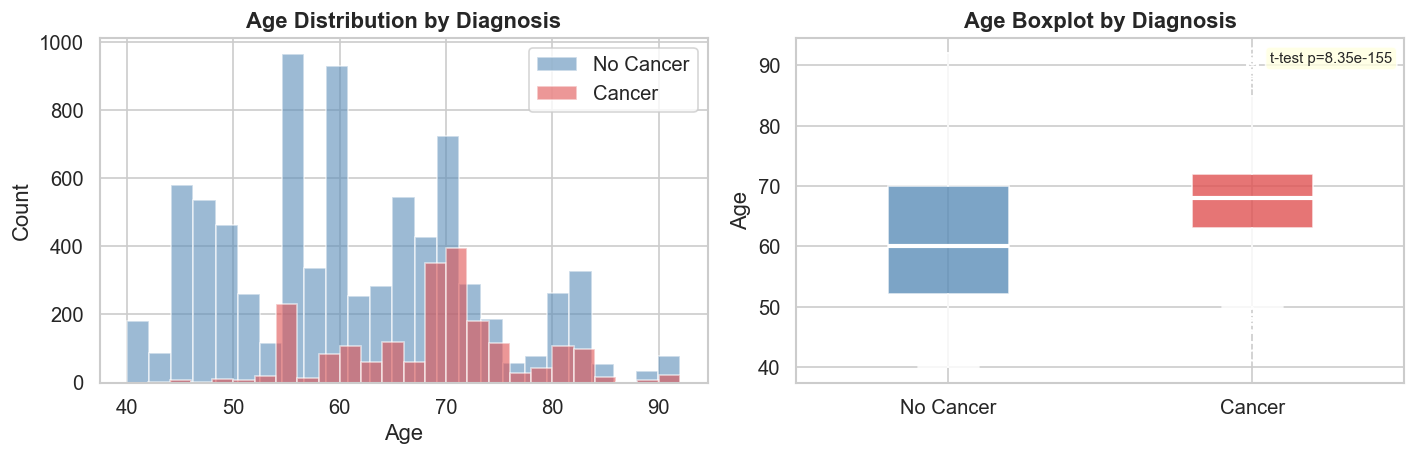

Mean age — No Cancer: 61.0  |  Cancer: 68.1  |  p=8.35e-155


In [6]:
# ── Age distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, grp in df.groupby('cancer_diagnosis'):
    tag = 'Cancer' if label == 1 else 'No Cancer'
    color = COLORS['yes'] if label == 1 else COLORS['no']
    axes[0].hist(grp['age'], bins=25, alpha=0.6, color=color, label=tag, edgecolor='white')

axes[0].set_title('Age Distribution by Diagnosis', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Boxplot age
groups = [df[df['cancer_diagnosis']==0]['age'], df[df['cancer_diagnosis']==1]['age']]
bp = axes[1].boxplot(groups, patch_artist=True, widths=0.4,
                      medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], [COLORS['no'], COLORS['yes']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['No Cancer', 'Cancer'])
axes[1].set_title('Age Boxplot by Diagnosis', fontweight='bold')
axes[1].set_ylabel('Age')

# Stat test
t, p = stats.ttest_ind(groups[0], groups[1])
axes[1].text(0.98, 0.96, f't-test p={p:.2e}', transform=axes[1].transAxes,
             ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.show()
print(f'Mean age — No Cancer: {groups[0].mean():.1f}  |  Cancer: {groups[1].mean():.1f}  |  p={p:.2e}')

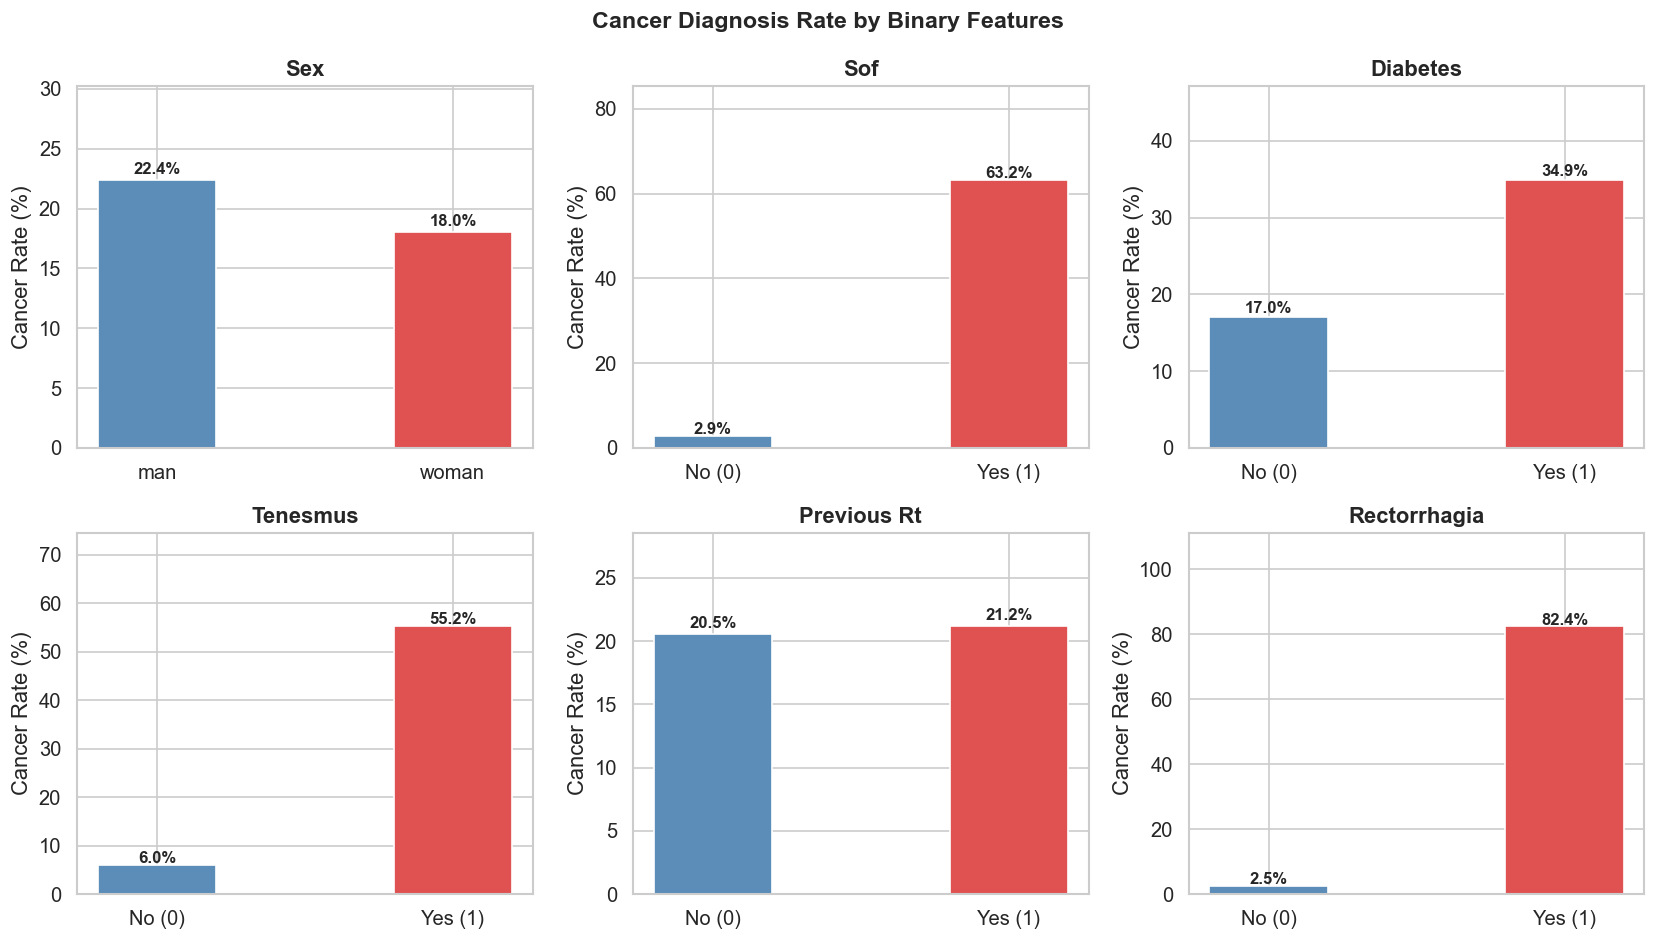

In [7]:
# ── Binary feature cancer rates ────────────────────────────────────────────
binary_features = ['sex', 'sof', 'diabetes', 'tenesmus', 'previous_rt', 'rectorrhagia']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, feat in zip(axes, binary_features):
    if feat == 'sex':
        rate = df.groupby('sex')['cancer_diagnosis'].mean() * 100
        cats = rate.index.tolist()
        vals = rate.values
    else:
        tbl = df.groupby(feat)['cancer_diagnosis'].mean() * 100
        cats = ['No (0)', 'Yes (1)']
        vals = [tbl.get(0, 0), tbl.get(1, 0)]

    bar_colors = [COLORS['no'], COLORS['yes']]
    bars = ax.bar(cats, vals, color=bar_colors, edgecolor='white', width=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%',
                ha='center', fontsize=10, fontweight='bold')
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Cancer Rate (%)')
    ax.set_ylim(0, max(vals)*1.35)

plt.suptitle('Cancer Diagnosis Rate by Binary Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

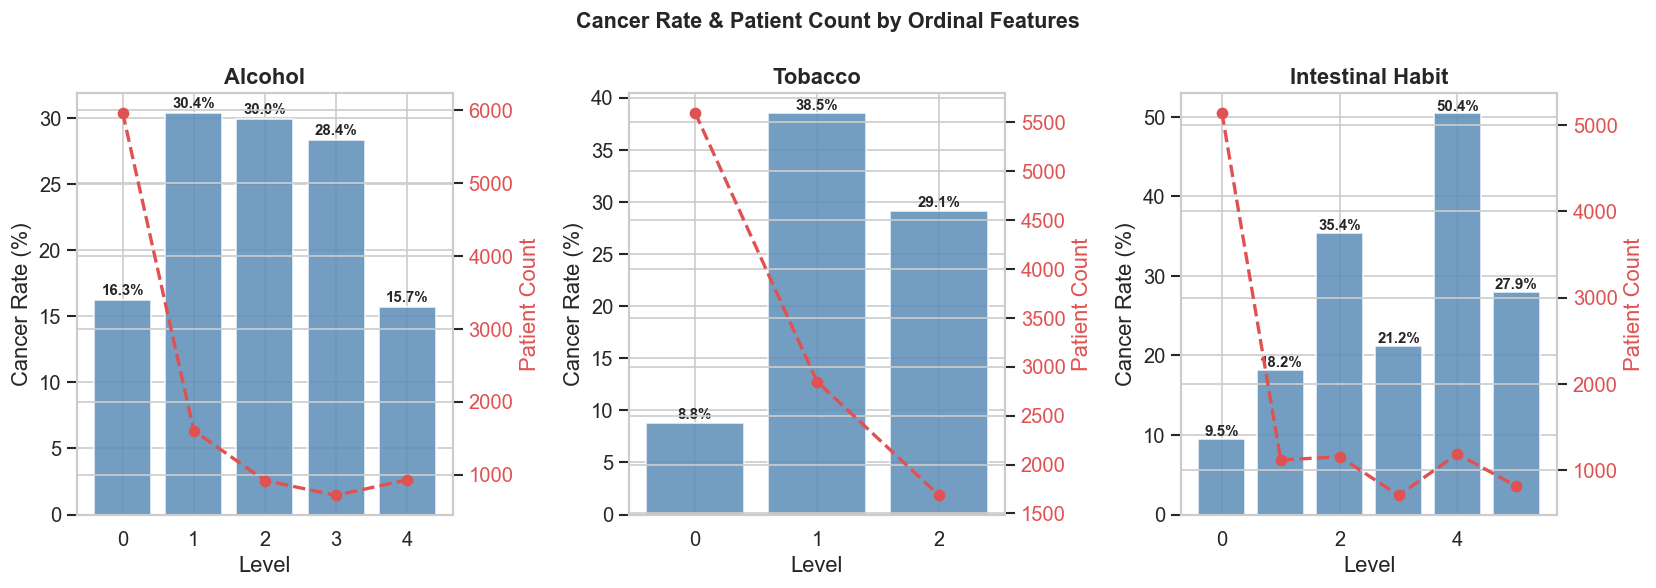

In [8]:
# ── Ordinal features ───────────────────────────────────────────────────────
ordinal_features = ['alcohol', 'tobacco', 'intestinal_habit']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, feat in zip(axes, ordinal_features):
    rate = df.groupby(feat)['cancer_diagnosis'].mean() * 100
    count = df.groupby(feat)['cancer_diagnosis'].count()
    ax.bar(rate.index, rate.values, color='#5B8DB8', edgecolor='white', alpha=0.85)
    ax2 = ax.twinx()
    ax2.plot(count.index, count.values, 'o--', color='#E05252', linewidth=2, markersize=6, label='Count')
    ax2.set_ylabel('Patient Count', color='#E05252')
    ax2.tick_params(axis='y', labelcolor='#E05252')
    for xi, yi in zip(rate.index, rate.values):
        ax.text(xi, yi+0.4, f'{yi:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Level')
    ax.set_ylabel('Cancer Rate (%)')

plt.suptitle('Cancer Rate & Patient Count by Ordinal Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

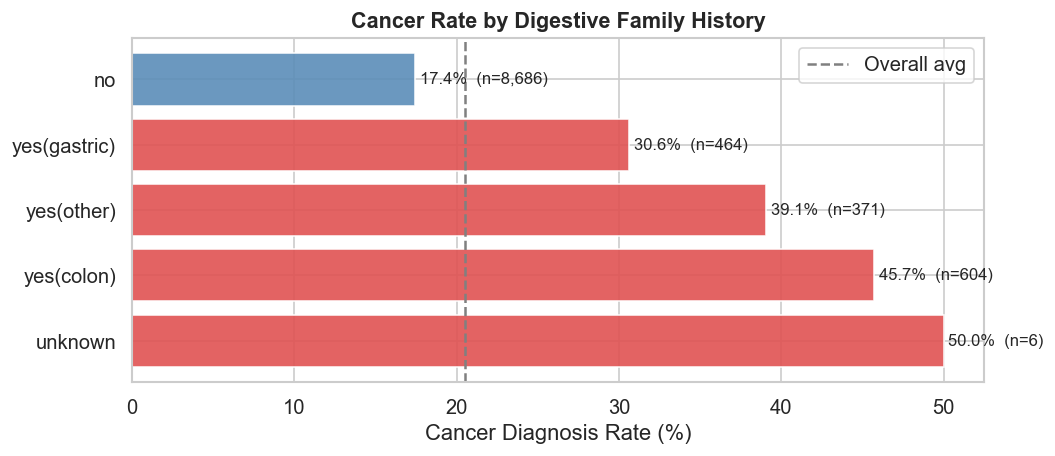

In [9]:
# ── Family history ─────────────────────────────────────────────────────────
rate_fh = df.groupby('digestive_family_history')['cancer_diagnosis'].mean().sort_values(ascending=False) * 100
count_fh = df.groupby('digestive_family_history')['cancer_diagnosis'].count()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(rate_fh.index, rate_fh.values,
               color=['#E05252' if v > 25 else '#5B8DB8' for v in rate_fh.values],
               edgecolor='white', alpha=0.9)
for bar, v, cat in zip(bars, rate_fh.values, rate_fh.index):
    n = count_fh[cat]
    ax.text(v+0.3, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}%  (n={n:,})', va='center', fontsize=10)
ax.set_xlabel('Cancer Diagnosis Rate (%)')
ax.set_title('Cancer Rate by Digestive Family History', fontsize=13, fontweight='bold')
ax.axvline(df['cancer_diagnosis'].mean()*100, color='gray', linestyle='--', linewidth=1.5, label='Overall avg')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

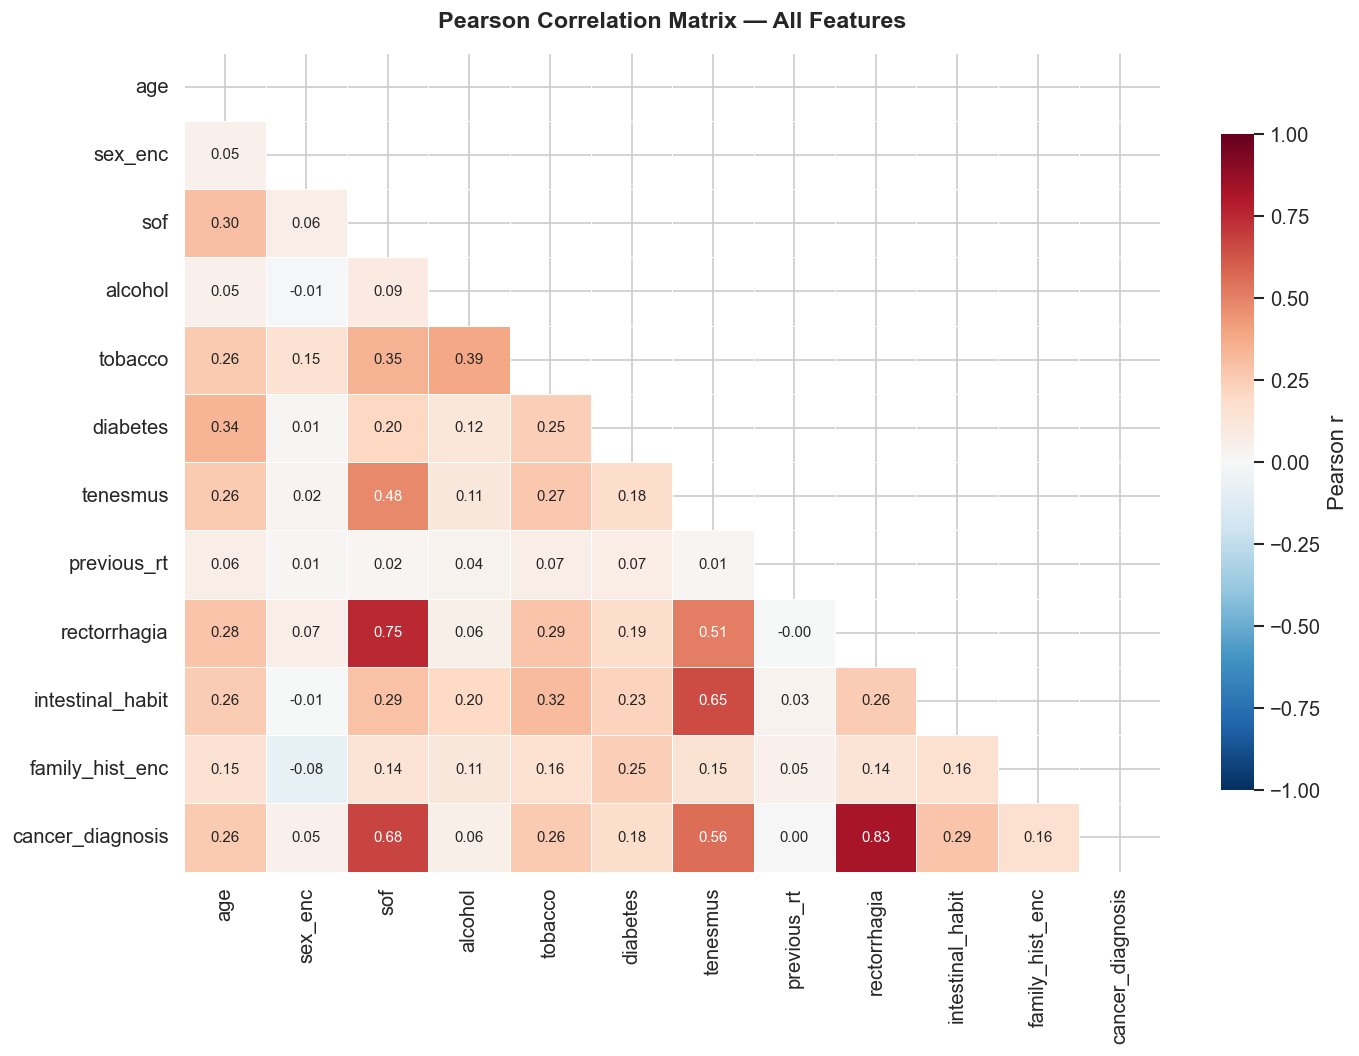

In [10]:
# ── Full Pearson correlation matrix ────────────────────────────────────────
corr = df_num.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9}, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Pearson Correlation Matrix — All Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [11]:
# ── Point-biserial correlations with target ────────────────────────────────
feature_cols = [c for c in num_cols if c != 'cancer_diagnosis']
labels_pretty = {
    'age': 'Age', 'sex_enc': 'Sex (man=1)',
    'sof': 'SOF', 'alcohol': 'Alcohol',
    'tobacco': 'Tobacco', 'diabetes': 'Diabetes',
    'tenesmus': 'Tenesmus', 'previous_rt': 'Previous RT',
    'rectorrhagia': 'Rectorrhagia', 'intestinal_habit': 'Intestinal Habit',
    'family_hist_enc': 'Family History'
}

results = []
for col in feature_cols:
    r, p = stats.pointbiserialr(df_num['cancer_diagnosis'], df_num[col])
    results.append({'Feature': labels_pretty[col], 'Correlation': r, 'p_value': p,
                    'Significant': '✓' if p < 0.05 else '✗'})

corr_df = pd.DataFrame(results).sort_values('Correlation', key=abs, ascending=False)
print('Point-Biserial Correlations with cancer_diagnosis:')
corr_df.style.background_gradient(subset=['Correlation'], cmap='RdBu_r', vmin=-0.4, vmax=0.4)

Point-Biserial Correlations with cancer_diagnosis:


,Feature,Correlation,p_value,Significant
8,Rectorrhagia,0.825727,0.000000,✓
2,SOF,0.679638,0.000000,✓
6,Tenesmus,0.555612,0.000000,✓
9,Intestinal Habit,0.286314,0.000000,✓
4,Tobacco,0.259208,0.000000,✓
0,Age,0.258868,0.000000,✓
5,Diabetes,0.175571,0.000000,✓
10,Family History,0.160869,0.000000,✓
3,Alcohol,0.058704,0.000000,✓
1,Sex (man=1),0.053190,0.000000,✓


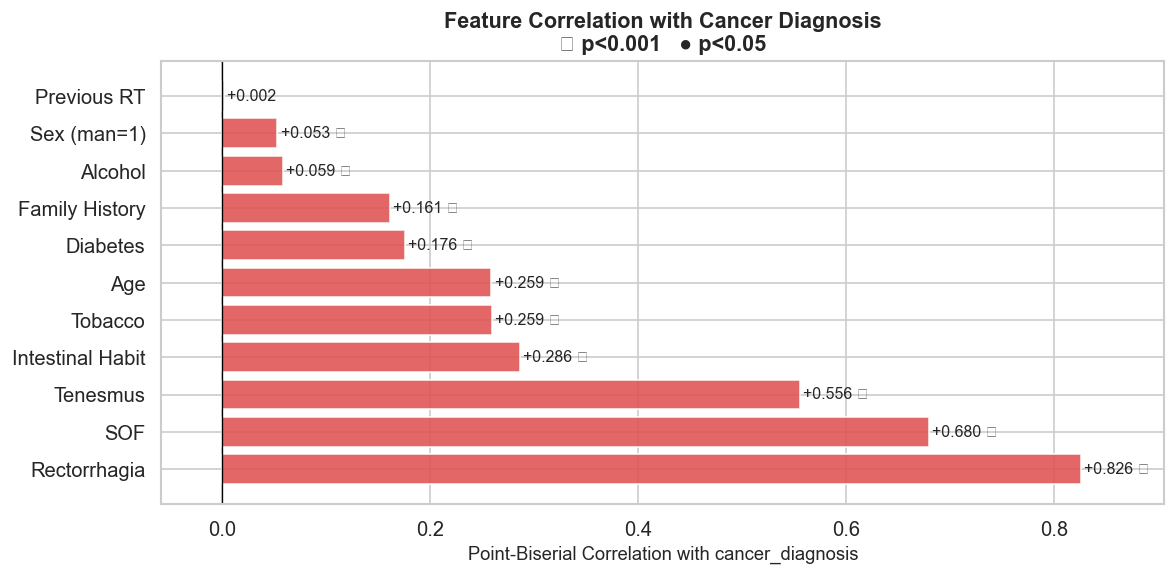

In [12]:
# ── Bar chart of correlations with target ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = ['#E05252' if v > 0 else '#5B8DB8' for v in corr_df['Correlation']]
bars = ax.barh(corr_df['Feature'], corr_df['Correlation'],
               color=bar_colors, edgecolor='white', alpha=0.88)

for bar, (_, row) in zip(bars, corr_df.iterrows()):
    x = row['Correlation']
    sig = '★' if row['p_value'] < 0.001 else ('●' if row['p_value'] < 0.05 else '')
    offset = 0.003 if x >= 0 else -0.003
    ha = 'left' if x >= 0 else 'right'
    ax.text(x + offset, bar.get_y()+bar.get_height()/2,
            f'{x:+.3f} {sig}', va='center', ha=ha, fontsize=9.5)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-Biserial Correlation with cancer_diagnosis', fontsize=11)
ax.set_title('Feature Correlation with Cancer Diagnosis\n★ p<0.001   ● p<0.05', fontsize=13, fontweight='bold')
ax.set_xlim(corr_df['Correlation'].min()-0.06, corr_df['Correlation'].max()+0.08)
plt.tight_layout()
plt.show()

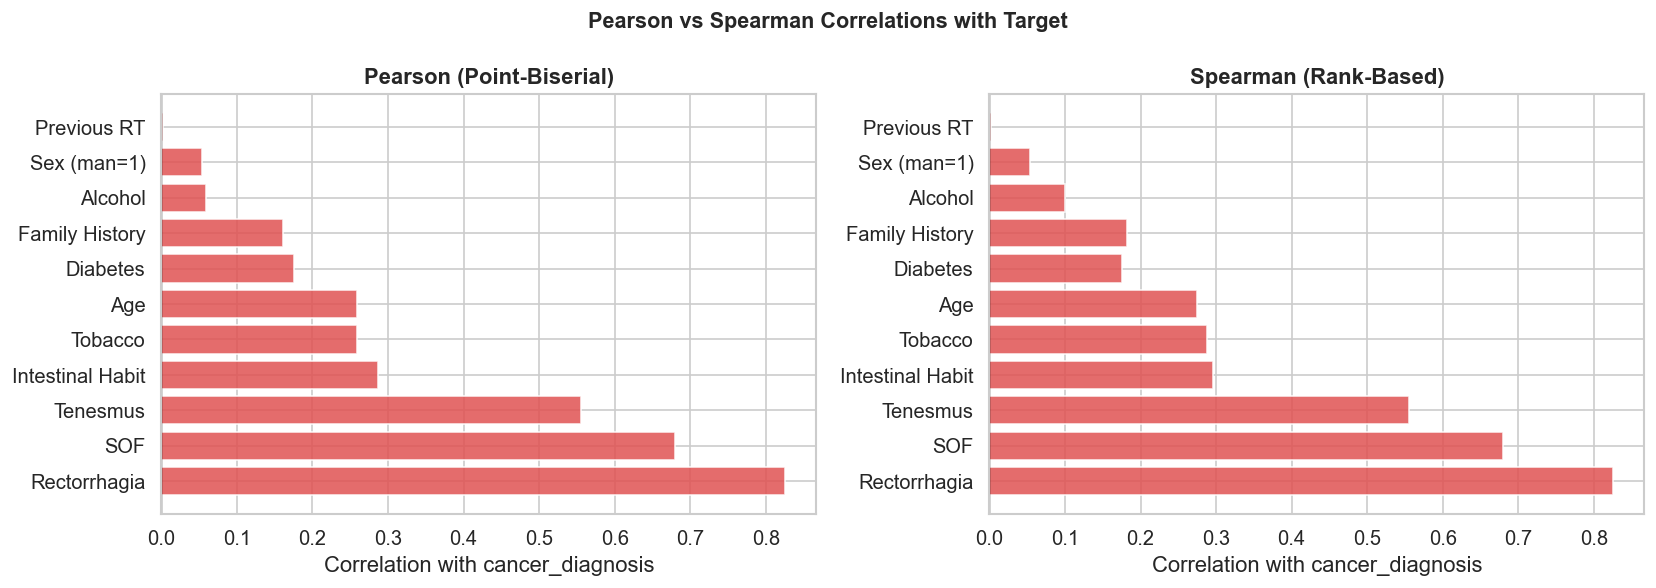

In [13]:
# ── Spearman correlations (rank-based, handles ordinal better) ─────────────
spearman_results = []
for col in feature_cols:
    r, p = stats.spearmanr(df_num['cancer_diagnosis'], df_num[col])
    spearman_results.append({'Feature': labels_pretty[col], 'Spearman r': r, 'p_value': p})

sp_df = pd.DataFrame(spearman_results).sort_values('Spearman r', key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df_plot, title) in zip(axes, [
    (corr_df.set_index('Feature')['Correlation'], 'Pearson (Point-Biserial)'),
    (sp_df.set_index('Feature')['Spearman r'],    'Spearman (Rank-Based)')
]):
    df_plot = df_plot.reindex(corr_df['Feature'])  # same order
    colors = ['#E05252' if v > 0 else '#5B8DB8' for v in df_plot.values]
    ax.barh(df_plot.index, df_plot.values, color=colors, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Correlation with cancer_diagnosis')

plt.suptitle('Pearson vs Spearman Correlations with Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Chi-Square Tests (Categorical Features)

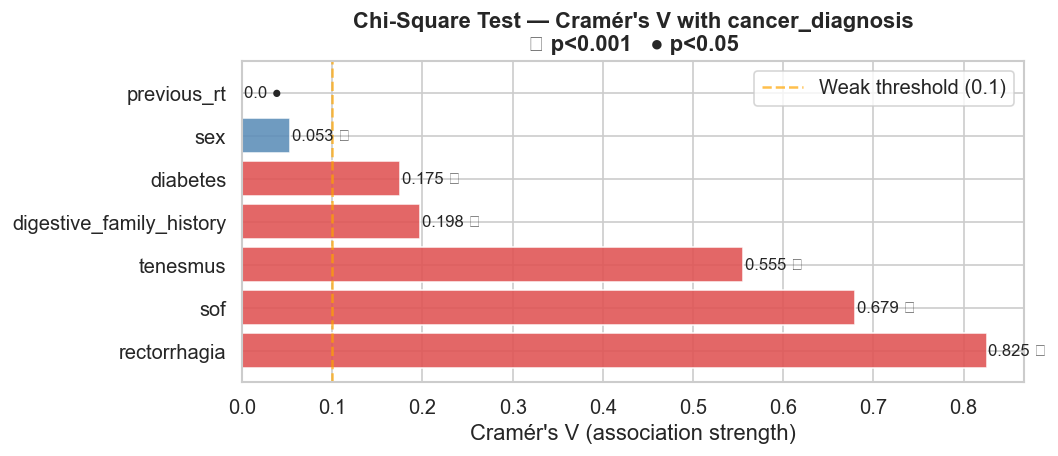

                 Feature        Chi2      p_value  Cramer's V  DoF
            rectorrhagia 6902.671192 0.000000e+00    0.825434    1
                     sof 4675.898071 0.000000e+00    0.679370    1
                tenesmus 3124.474916 0.000000e+00    0.555344    1
digestive_family_history  395.395898 2.748305e-84    0.197556    4
                diabetes  311.195754 1.198779e-69    0.175263    1
                     sex   28.396545 9.884157e-08    0.052943    1
             previous_rt    0.001125 9.732488e-01    0.000333    1


In [14]:
from scipy.stats import chi2_contingency

cat_features = ['sex', 'sof', 'diabetes', 'tenesmus', 'previous_rt',
                'rectorrhagia', 'digestive_family_history']

chi2_results = []
for feat in cat_features:
    ct = pd.crosstab(df[feat], df['cancer_diagnosis'])
    chi2, p, dof, _ = chi2_contingency(ct)
    # Cramér's V
    n = ct.sum().sum()
    v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))
    chi2_results.append({'Feature': feat, 'Chi2': chi2, 'p_value': p, "Cramer's V": v, 'DoF': dof})

chi2_df = pd.DataFrame(chi2_results).sort_values("Cramer's V", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['#E05252' if v > 0.1 else '#5B8DB8' for v in chi2_df["Cramer's V"]]
bars = ax.barh(chi2_df['Feature'], chi2_df["Cramer's V"], color=bar_colors, edgecolor='white', alpha=0.88)
for bar, (_, row) in zip(bars, chi2_df.iterrows()):
    sig = '★' if row['p_value'] < 0.001 else '●'
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            (str(round(row["Cramer's V"], 3)) + " " + sig), va='center', fontsize=10)
ax.axvline(0.1, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Weak threshold (0.1)')
ax.set_xlabel("Cramér's V (association strength)")
ax.set_title("Chi-Square Test — Cramér's V with cancer_diagnosis\n★ p<0.001   ● p<0.05", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(chi2_df.to_string(index=False))


## 8. Pairwise Feature Interactions

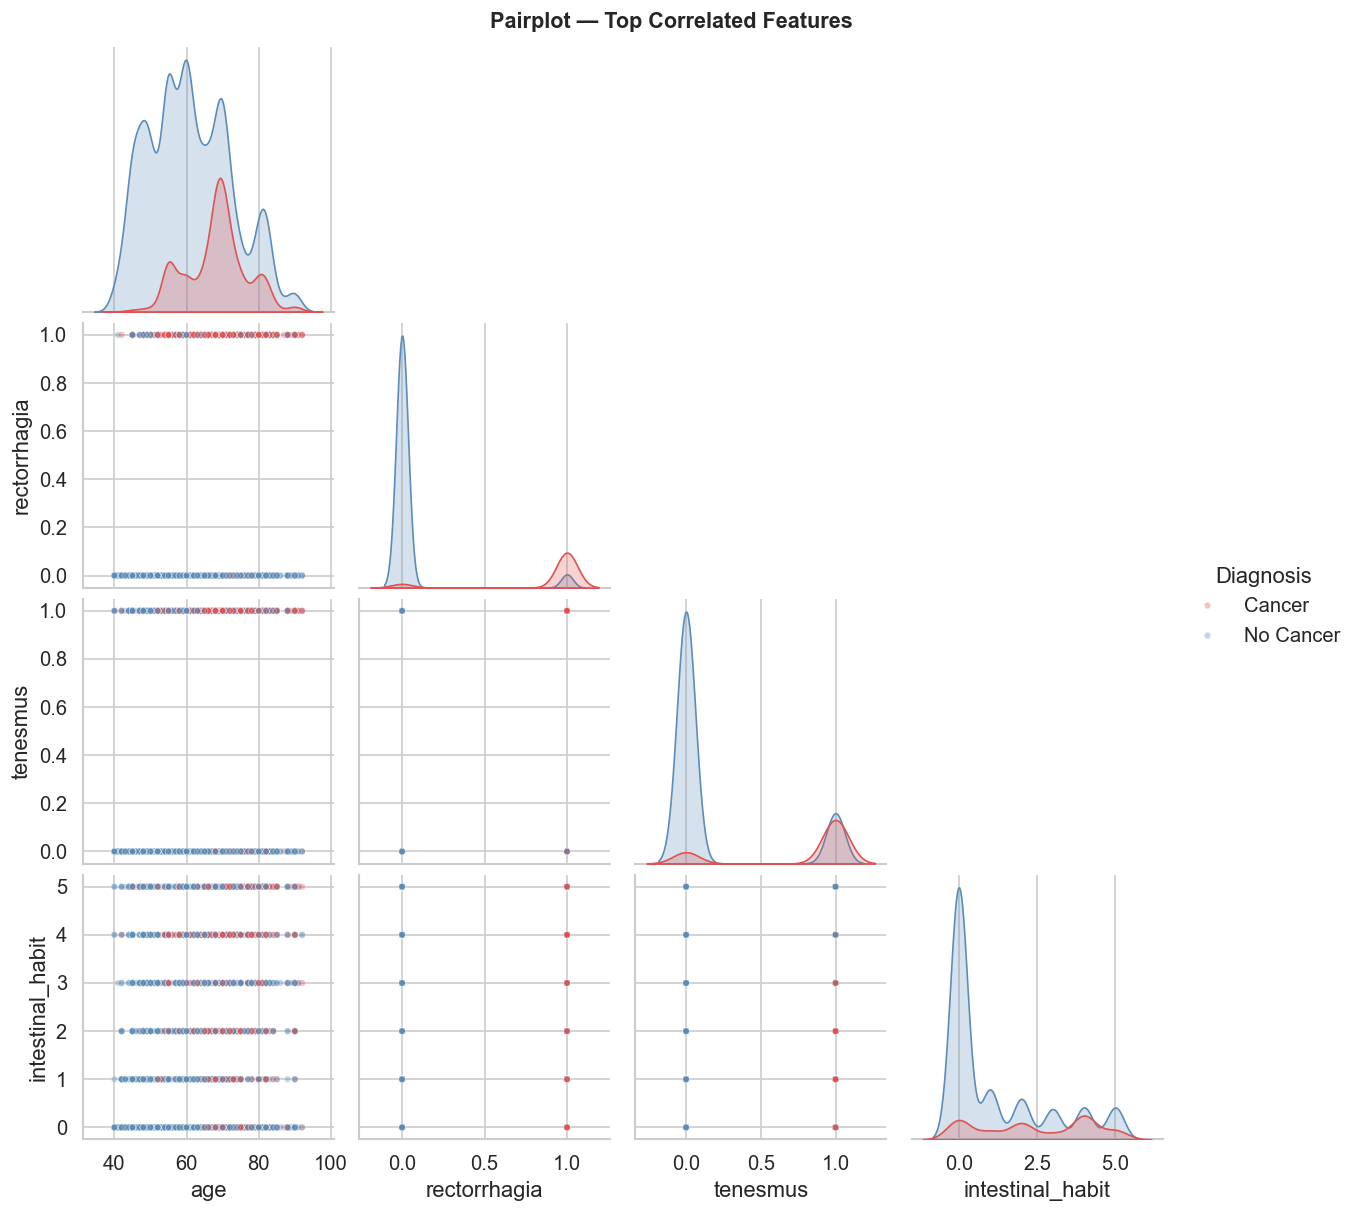

In [15]:
# ── Top features pairplot ──────────────────────────────────────────────────
top_feats = ['age', 'rectorrhagia', 'tenesmus', 'intestinal_habit', 'cancer_diagnosis']
plot_df = df_num[top_feats].copy()
plot_df['Diagnosis'] = plot_df['cancer_diagnosis'].map({0: 'No Cancer', 1: 'Cancer'})

pp = sns.pairplot(plot_df.drop(columns='cancer_diagnosis'),
                  hue='Diagnosis', corner=True,
                  palette={'No Cancer': COLORS['no'], 'Cancer': COLORS['yes']},
                  diag_kind='kde', plot_kws={'alpha': 0.35, 's': 15})
pp.fig.suptitle('Pairplot — Top Correlated Features', y=1.01, fontsize=13, fontweight='bold')
plt.show()

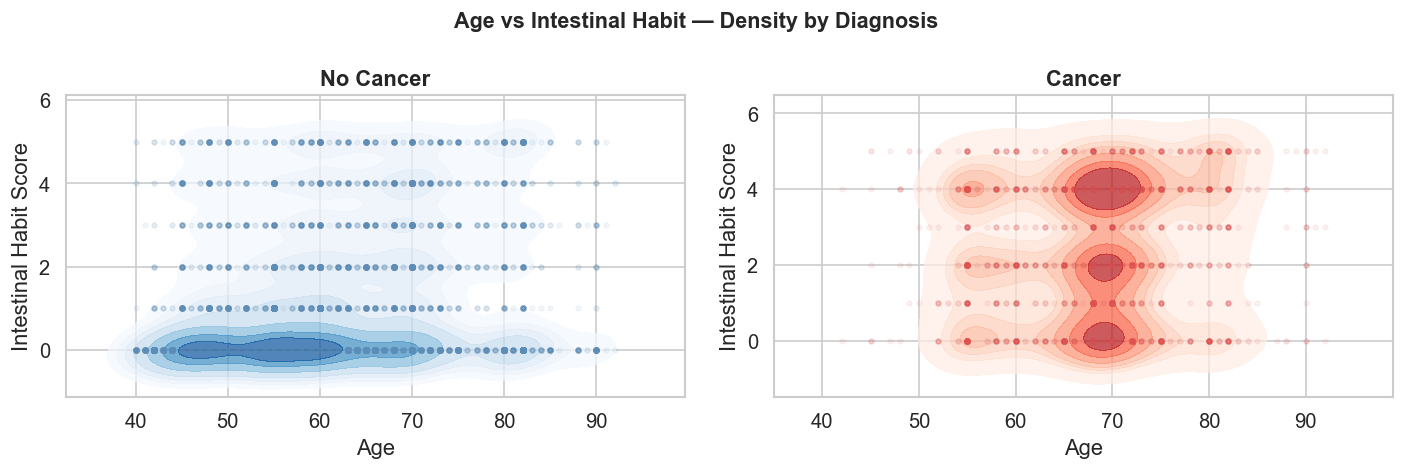

In [16]:
# ── Age vs Intestinal Habit — 2D density ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label, grp) in zip(axes, df.groupby('cancer_diagnosis')):
    tag = 'Cancer' if label == 1 else 'No Cancer'
    color = COLORS['yes'] if label == 1 else COLORS['no']
    sns.kdeplot(data=grp, x='age', y='intestinal_habit',
                fill=True, cmap='Reds' if label==1 else 'Blues',
                ax=ax, levels=8, alpha=0.7)
    ax.scatter(grp['age'], grp['intestinal_habit'], alpha=0.07, s=8, color=color)
    ax.set_title(f'{tag}', fontweight='bold')
    ax.set_xlabel('Age')
    ax.set_ylabel('Intestinal Habit Score')

plt.suptitle('Age vs Intestinal Habit — Density by Diagnosis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Summary — Key Findings

In [17]:
print('=' * 65)
print('           ANALYSIS SUMMARY')
print('=' * 65)
print(f'  Total patients    : {len(df):,}')
print(f'  Cancer cases      : {df["cancer_diagnosis"].sum():,} ({df["cancer_diagnosis"].mean()*100:.1f}%)')
print(f'  No cancer cases   : {(df["cancer_diagnosis"]==0).sum():,} ({(1-df["cancer_diagnosis"].mean())*100:.1f}%)')
print(f'  Missing values    : None')
print()
print('  TOP FEATURES (by Pearson |r| with target):')
top = corr_df.head(5)
for _, row in top.iterrows():
    bar = '█' * int(abs(row['Correlation']) * 50)
    print(f"  {row['Feature']:20s}  r={row['Correlation']:+.3f}  {bar}")
print()
print('  STATISTICALLY SIGNIFICANT (Chi-Sq p<0.001):')
sig = chi2_df[chi2_df['p_value'] < 0.001]
for _, row in sig.iterrows():
    print(f"  {row['Feature']:30s}  V=" + str(round(row["Cramer's V"], 3)))
print()
print('  CLASS IMBALANCE: ~4:1 → use SMOTE or class_weight=balanced')
print('  RECOMMENDED MODELS: Logistic Regression, Random Forest, XGBoost')
print('=' * 65)

           ANALYSIS SUMMARY
  Total patients    : 10,131
  Cancer cases      : 2,081 (20.5%)
  No cancer cases   : 8,050 (79.5%)
  Missing values    : None

  TOP FEATURES (by Pearson |r| with target):
  Rectorrhagia          r=+0.826  █████████████████████████████████████████
  SOF                   r=+0.680  █████████████████████████████████
  Tenesmus              r=+0.556  ███████████████████████████
  Intestinal Habit      r=+0.286  ██████████████
  Tobacco               r=+0.259  ████████████

  STATISTICALLY SIGNIFICANT (Chi-Sq p<0.001):
  rectorrhagia                    V=0.825
  sof                             V=0.679
  tenesmus                        V=0.555
  digestive_family_history        V=0.198
  diabetes                        V=0.175
  sex                             V=0.053

  CLASS IMBALANCE: ~4:1 → use SMOTE or class_weight=balanced
  RECOMMENDED MODELS: Logistic Regression, Random Forest, XGBoost
